# 04 · Angle 2 — FAR as a natural experiment

The Financial Accountability Regime commenced in two waves: banking (ADI) on
**15 March 2024**, insurance and superannuation on **15 March 2025**. Same
obligations, same company, twelve months apart. That stagger is the closest
thing to a randomised trial that a people dataset ever offers — the second
wave is a control group for the first, and then becomes treated itself.

The claim to test: *did personal accountability under FAR push senior
risk-and-compliance staff out?*

> Carry-forward from `02`: December 2025 is censored. Any post-treatment
> window that runs to the end of the data is short.

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib
import sys

_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "etl.py").exists())
sys.path.insert(0, str(_root / "src"))

from nbinit import *

df = load("analysis_df")
monthly = load("monthly_exits")

## 1. Validate the wave map before trusting anything downstream

`etl.FAR_WAVE_MAP` assigns each department to a wave. It was written from the
brief, before anyone had seen the department values. Check it first — an
unmapped department silently becomes an `Unmapped` bucket that quietly drops
out of every comparison.

In [2]:
in_data = set(df["department"].dropna().unique())
in_map = set(etl.FAR_WAVE_MAP)

print("  mapped to a FAR wave:")
for dept, date in sorted(etl.FAR_WAVE_MAP.items(), key=lambda kv: (kv[1], kv[0])):
    present = "" if dept in in_data else "   <-- NOT IN DATA"
    print(f"    {dept:<24} {date:%d %b %Y}{present}")

unmapped = sorted(in_data - in_map)
print(f"\n  in the data but NOT mapped: {unmapped}")
print(f"  employees affected: {df['department'].isin(unmapped).sum():,}")

  mapped to a FAR wave:
    Corporate Operations     15 Mar 2024
    Retail Banking           15 Mar 2024
    Risk & Compliance        15 Mar 2024
    Technology               15 Mar 2024
    Insurance                15 Mar 2025
    Wealth Management        15 Mar 2025

  in the data but NOT mapped: ['Executive Leadership']
  employees affected: 230


`Executive Leadership` is unmapped. Its 230 people are the population most
directly exposed to FAR — accountable persons are, by definition, senior.
Leaving them out understates the effect.

They sit across both regulated arms, so there is no single correct wave for
them. The honest options are to report them separately or to exclude them and
say so. This notebook keeps them visible as their own bucket.

In [3]:
wave_summary = df.groupby("far_wave", observed=True).agg(
    headcount=("employee_id", "size"),
    departed=("is_departed", "sum"),
    far_exposed=("far_exposed", "sum"),
    senior_exposed=("far_exposed_senior", "sum"),
)
wave_summary["attrition_pct"] = (100 * wave_summary["departed"] / wave_summary["headcount"]).round(1)
wave_summary

,headcount,departed,far_exposed,senior_exposed,attrition_pct
far_wave,,,,,
Unmapped,230,19,34,1,8.30
"Wave 1 (ADI, Mar-2024)",9843,1035,3104,94,10.50
"Wave 2 (Ins/Super, Mar-2025)",3330,346,476,20,10.40


## 2. How much post-treatment data does each wave actually have?

This governs what the comparison can support, so it goes before the charts
rather than in a footnote.

In [4]:
data_end = df["exit_date"].max()
coverage = pd.DataFrame([
    {"wave": "Wave 1 (ADI)", "commenced": etl.FAR_ADI},
    {"wave": "Wave 2 (Ins/Super)", "commenced": etl.FAR_INSURANCE_SUPER},
])
coverage["months_pre"] = ((coverage["commenced"] - df["exit_date"].min()).dt.days / 30.44).round(1)
coverage["months_post"] = ((data_end - coverage["commenced"]).dt.days / 30.44).round(1)
coverage

,wave,commenced,months_pre,months_post
0,Wave 1 (ADI),2024-03-15,1.40,21.60
1,Wave 2 (Ins/Super),2025-03-15,13.40,9.60


Wave 1 has **1.4 months** of pre-period and ~21.6 months post. Wave 2 has
~13.4 months pre and ~9.6 post.

**This is the central limitation of the whole angle, and it is fatal for
Wave 1.** The dataset begins in January 2024; FAR commenced for ADIs in March
2024. There is no pre-period to compare against — not a short one, effectively
none. Any Wave 1 before/after number is measuring the length of the window,
not the effect of the regulation.

That leaves two honest moves, and this notebook makes both:

1. **Wave 2 is the identified experiment.** It has 13 months of pre-period,
   and during those months Wave 1 was already treated — so Wave 1 serves as
   the already-treated comparison group. This is the standard staggered
   design, and it is the only one this data supports.
2. **Within-wave difference-in-differences.** Comparing regulated against
   unregulated roles *inside the same wave and the same window* means the
   truncation applies identically to both, so it differences out.

Everything below is reported for both waves, with Wave 1's numbers marked as
unidentified rather than quietly dropped.

## 3. Event study

Exits per month, indexed to each wave's own commencement date, as a rate per
1,000 exposed employees so the two waves are comparable despite very
different headcounts. Monthly counts on a few hundred people are noisy, so
the line is a 3-month centred rolling mean with the raw months behind it.

In [5]:
exposed = df[df["far_exposed"] & df["far_date"].notna()].copy()
denominator = exposed.groupby("far_wave", observed=True).size()

events = exposed[exposed["exit_date"].notna()].copy()
events["month_rel"] = np.floor(events["months_to_far_at_exit"]).astype(int)

study = (
    events.groupby(["far_wave", "month_rel"], observed=True)
    .size().rename("exits").reset_index()
)
study["exposed"] = study["far_wave"].map(denominator)
study["rate_per_1000"] = 1000 * study["exits"] / study["exposed"]

# Trim to the window both waves can support, so neither is flattered by
# a longer tail than the other.
WINDOW = 9
study = study[study["month_rel"].between(-WINDOW, WINDOW)]
study.head()

,far_wave,month_rel,exits,exposed,rate_per_1000
0,"Wave 1 (ADI, Mar-2024)",-2,7,3104,2.26
1,"Wave 1 (ADI, Mar-2024)",-1,10,3104,3.22
2,"Wave 1 (ADI, Mar-2024)",0,16,3104,5.15
3,"Wave 1 (ADI, Mar-2024)",1,12,3104,3.87
4,"Wave 1 (ADI, Mar-2024)",2,13,3104,4.19


  saved figures\a2_event_study.png


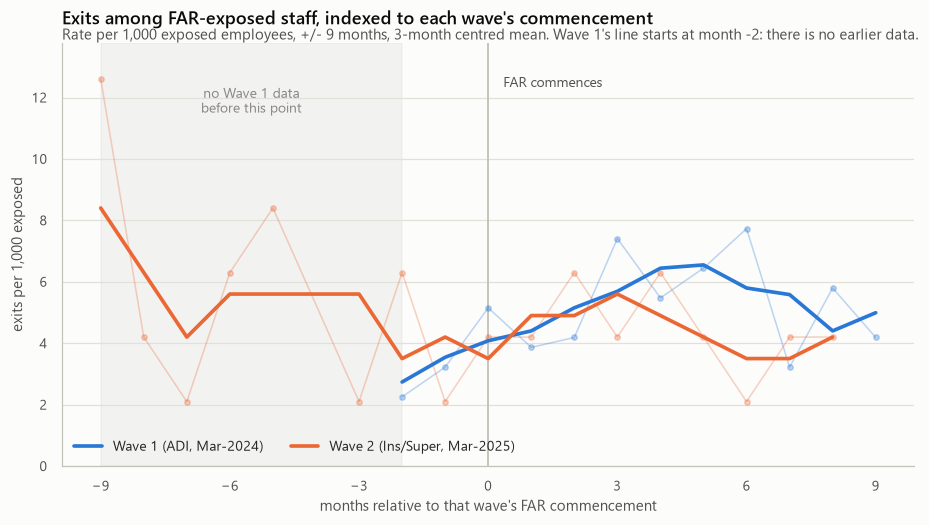

In [6]:
fig, ax = figure(
    "Exits among FAR-exposed staff, indexed to each wave's commencement",
    f"Rate per 1,000 exposed employees, +/- {WINDOW} months, 3-month centred mean. "
    "Wave 1's line starts at month -2: there is no earlier data.",
    figsize=(10, 5.0),
)

for i, wave in enumerate(sorted(study["far_wave"].unique())):
    sub = study[study["far_wave"] == wave].sort_values("month_rel")
    smooth = sub["rate_per_1000"].rolling(3, center=True, min_periods=2).mean()
    ax.plot(sub["month_rel"], sub["rate_per_1000"], color=SERIES[i],
            lw=1, alpha=0.30, marker="o", markersize=3.5, zorder=2)
    ax.plot(sub["month_rel"], smooth, color=SERIES[i], lw=2.4, label=wave, zorder=3)

ax.axvline(0, color=INK["axis"], lw=1.2, zorder=1)

top = ax.get_ylim()[1]
ax.annotate("FAR commences", xy=(0.35, top * 0.94), fontsize=9, color=INK["secondary"])
ax.axvspan(-WINDOW, -2, color=INK["muted"], alpha=0.08, zorder=0)
ax.annotate("no Wave 1 data\nbefore this point", xy=(-5.5, top * 0.94), ha="center",
            va="top", fontsize=9, color=INK["muted"])

ax.set(xlabel="months relative to that wave's FAR commencement",
       ylabel="exits per 1,000 exposed", ylim=(0, top * 1.05))
ax.set_xticks(range(-WINDOW, WINDOW + 1, 3))
ax.legend(loc="lower left", ncols=2)
save_fig(fig, "a2_event_study")
plt.show()

### Pre/post as a number — and why Wave 1's is not usable

`months_observed_pre` is the column that matters. A ratio computed against
1.4 months of pre-period is not a finding.

In [7]:
rows = []
for wave, sub in study.groupby("far_wave", observed=True):
    pre = sub.loc[sub["month_rel"].between(-WINDOW, -1), "exits"].sum()
    post = sub.loc[sub["month_rel"].between(0, WINDOW - 1), "exits"].sum()
    months_pre = coverage.loc[coverage["wave"].str.startswith(wave.split(" (")[0]),
                              "months_pre"].iloc[0]
    rows.append({
        "far_wave": wave,
        "exposed": int(denominator[wave]),
        "months_observed_pre": min(months_pre, WINDOW),
        f"exits_pre_{WINDOW}m": int(pre),
        f"exits_post_{WINDOW}m": int(post),
        "raw_ratio": round(post / pre, 2) if pre else np.nan,
        "identified": months_pre >= WINDOW,
    })
prepost = pd.DataFrame(rows)
prepost

,far_wave,exposed,months_observed_pre,exits_pre_9m,exits_post_9m,raw_ratio,identified
0,"Wave 1 (ADI, Mar-2024)",3104,1.40,17,153,9.00,False
1,"Wave 2 (Ins/Super, Mar-2025)",476,9.00,21,19,0.90,True


Wave 1's 9x is an artefact — 1.4 months of pre-period against 9 months of
post. Wave 2, the wave with a real pre-period, sits just **below** 1.0: its
regulated staff left slightly *less* often after commencement than before.

That is the opposite of the expected result, and it is the honest headline.

## 4. Difference-in-differences: exposed vs not, within each wave

A rise in exits after March 2024 could just be a rise in exits. The test that
isolates FAR is whether the rise is **larger for regulated roles than for
their unregulated colleagues in the same wave** — same company, same market,
same twelve months.

In [8]:
did_rows = []
for wave, sub in df[df["far_date"].notna()].groupby("far_wave", observed=True):
    for is_exposed in [False, True]:
        grp = sub[sub["far_exposed"] == is_exposed]
        left = grp[grp["months_to_far_at_exit"].between(-WINDOW, -1)]
        right = grp[grp["months_to_far_at_exit"].between(0, WINDOW - 1)]
        did_rows.append({
            "far_wave": wave,
            "group": "FAR-exposed roles" if is_exposed else "All other roles",
            "headcount": len(grp),
            "pre_per_1000": round(1000 * len(left) / len(grp), 1),
            "post_per_1000": round(1000 * len(right) / len(grp), 1),
        })

did = pd.DataFrame(did_rows)
did["change"] = (did["post_per_1000"] - did["pre_per_1000"]).round(1)
did

,far_wave,group,headcount,pre_per_1000,post_per_1000,change
0,"Wave 1 (ADI, Mar-2024)",All other roles,6739,1.60,37.20,35.60
1,"Wave 1 (ADI, Mar-2024)",FAR-exposed roles,3104,2.60,43.80,41.20
2,"Wave 2 (Ins/Super, Mar-2025)",All other roles,2854,42.70,39.90,-2.80
3,"Wave 2 (Ins/Super, Mar-2025)",FAR-exposed roles,476,42.00,35.70,-6.30


In [9]:
for wave, sub in did.groupby("far_wave", observed=True):
    exposed_change = sub.loc[sub["group"] == "FAR-exposed roles", "change"].iloc[0]
    other_change = sub.loc[sub["group"] == "All other roles", "change"].iloc[0]
    print(f"  {wave}")
    print(f"    FAR-exposed roles change : {exposed_change:+.1f} per 1,000")
    print(f"    All other roles change   : {other_change:+.1f} per 1,000")
    print(f"    difference-in-differences: {exposed_change - other_change:+.1f}\n")

  Wave 1 (ADI, Mar-2024)
    FAR-exposed roles change : +41.2 per 1,000
    All other roles change   : +35.6 per 1,000
    difference-in-differences: +5.6

  Wave 2 (Ins/Super, Mar-2025)
    FAR-exposed roles change : -6.3 per 1,000
    All other roles change   : -2.8 per 1,000
    difference-in-differences: -3.5



  saved figures\a2_did.png


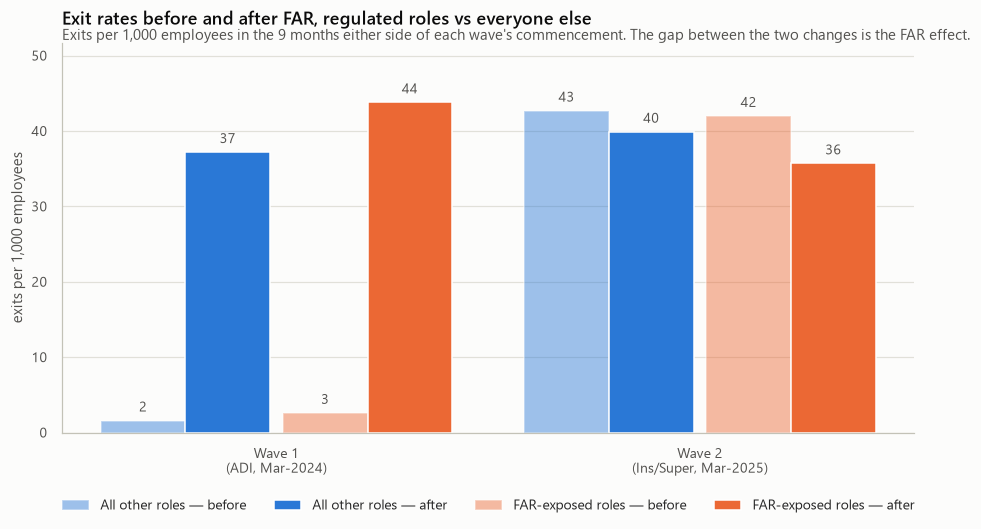

In [10]:
fig, ax = figure(
    "Exit rates before and after FAR, regulated roles vs everyone else",
    f"Exits per 1,000 employees in the {WINDOW} months either side of each wave's "
    "commencement. The gap between the two changes is the FAR effect.",
    figsize=(10, 4.6),
)

waves_present = sorted(did["far_wave"].unique())
x = np.arange(len(waves_present))
width = 0.2

for i, (group, colour) in enumerate([("All other roles", SERIES[0]),
                                     ("FAR-exposed roles", SERIES[1])]):
    sub = did[did["group"] == group].set_index("far_wave").loc[waves_present]
    ax.bar(x + (i - 0.5) * (2 * width + 0.03) - width / 2, sub["pre_per_1000"],
           width, color=colour, alpha=0.45, label=f"{group} — before")
    ax.bar(x + (i - 0.5) * (2 * width + 0.03) + width / 2, sub["post_per_1000"],
           width, color=colour, label=f"{group} — after")

label_bars(ax, "{:,.0f}")
ax.set_xticks(x, [w.replace(" (", "\n(") for w in waves_present])
ax.set(ylabel="exits per 1,000 employees", xlabel="",
       ylim=(0, did[["pre_per_1000", "post_per_1000"]].to_numpy().max() * 1.18))
ax.legend(ncols=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
save_fig(fig, "a2_did")
plt.show()

Read the two panels differently, because they are not equally trustworthy:

- **Wave 1** — both "before" bars are near zero because the pre-window is 1.4
  months long. The *levels* are meaningless. The difference-in-differences
  (+5.6 per 1,000) is still interpretable, because the truncation hits both
  groups identically, but it rests on a pre-period of six weeks.
- **Wave 2** — both groups have a genuine 9-month pre-period, and both fall
  after commencement. Regulated roles fall *further* (-6.3 vs -2.8 per
  1,000), giving a difference-in-differences of **-3.5**.

On the only wave this dataset can identify, FAR is associated with slightly
**lower** exit rates among the staff it regulates.

## 5. Does it bite hardest where accountability is personal?

FAR's obligations attach to *accountable persons* — senior staff with named
responsibilities. If the mechanism is real, the effect should scale with
seniority within the exposed population, not sit flat across it.

In [11]:
seniority = rate_table(
    df[df["far_exposed"] & df["far_date"].notna()],
    ["far_wave", "is_senior"],
).rename(index={False: "role level 1–4", True: "role level 5+"}, level=1)
seniority

,,n,events,rate_pct
far_wave,is_senior,,,
"Wave 2 (Ins/Super, Mar-2025)",role level 5+,6,1,16.70
"Wave 1 (ADI, Mar-2024)",role level 1–4,3082,352,11.40
"Wave 2 (Ins/Super, Mar-2025)",role level 1–4,470,50,10.60
"Wave 1 (ADI, Mar-2024)",role level 5+,22,1,4.50


In [12]:
acting = rate_table(df[df["far_exposed"]], "acting_appointment")
print("  Attrition among FAR-exposed staff, by whether they are in an acting role:")
print(acting.to_string())

  Attrition among FAR-exposed staff, by whether they are in an acting role:
                       n  events  rate_pct
acting_appointment                        
False               3586     405     11.30
True                  28       2      7.10


**Both of these cuts are too small to report.** There are 22 senior
FAR-exposed employees in Wave 1 and 6 in Wave 2; 28 exposed staff hold acting
appointments. One departure moves a rate by five to seventeen points.

The mechanism is right — FAR attaches to accountable persons, so seniority is
exactly where the effect should concentrate — but this dataset cannot test
it. Say that on the slide rather than quoting a 16.7% built on six people.
The cell below makes the constraint explicit so nobody is tempted later.

In [13]:
for label, frame in [("Wave 1 senior exposed", df[df["far_exposed_senior"] & (df["far_date"] == etl.FAR_ADI)]),
                     ("Wave 2 senior exposed", df[df["far_exposed_senior"] & (df["far_date"] == etl.FAR_INSURANCE_SUPER)]),
                     ("Acting + FAR-exposed", df[df["far_exposed"] & df["acting_appointment"].fillna(False)])]:
    n, events = len(frame), int(frame["is_departed"].sum())
    swing = 100 / n if n else np.nan
    print(f"  {label:<24} n={n:>4}  departures={events:>3}  "
          f"one more departure moves the rate by {swing:.1f}pp")

  Wave 1 senior exposed    n=  94  departures= 14  one more departure moves the rate by 1.1pp
  Wave 2 senior exposed    n=  20  departures=  1  one more departure moves the rate by 5.0pp
  Acting + FAR-exposed     n=  28  departures=  2  one more departure moves the rate by 3.6pp


## 6. What else changed at the same time?

The honest caveat. March 2024 is not the only thing that happened to this
company — the Entity_B and Entity_C acquisitions are also in this window. If
the exposed and unexposed groups have different legacy-entity mixes, the
"FAR effect" may be an integration effect wearing a lanyard.

In [14]:
confound = pd.crosstab(df["far_exposed"], df["legacy_entity_code"], normalize="index")
(100 * confound).round(1)

legacy_entity_code,Entity_A,Entity_B,Entity_C,NovaCorp-Origin
far_exposed,,,,
False,14.00,15.00,7.70,63.30
True,16.00,11.50,7.30,65.20


In [15]:
by_entity = rate_table(df[df["far_exposed"]], "legacy_entity_code")
print("  Attrition among FAR-exposed staff, split by legacy entity:")
print(by_entity.to_string())

  Attrition among FAR-exposed staff, split by legacy entity:
                       n  events  rate_pct
legacy_entity_code                        
Entity_B             414      71     17.10
NovaCorp-Origin     2358     264     11.20
Entity_C             265      26      9.80
Entity_A             577      46      8.00


## 7. The design this data actually wants

Sections 3 and 4 work *around* the truncation. The staggered design removes
it: align on **Wave 2's** commencement, and compare Wave 2 (newly treated)
against Wave 1 (already treated, twelve months earlier) over the same calendar
months. Both arms are then observed across an identical window, so neither can
be flattered by a longer tail. This is the comparison the two-wave stagger was
always for.

`study` cannot be reused here — it is indexed to each wave's *own*
commencement and trimmed to ±9 months around it, so its Wave 1 rows stop in
Dec 2024, before this window opens. The frame below rebuilds the same counts
from `exposed` on a calendar clock: same population, same denominators,
different origin.

In [16]:
# Wave 2's commencement is the only event date with a real pre-period, so it
# is the one to align on. By then Wave 1 is twelve months into its own
# treatment, which is what makes it a control rather than a second treatment.
EVENT = etl.FAR_INSURANCE_SUPER

cal_events = exposed[exposed["exit_date"].notna()].copy()
cal_events["month_cal"] = np.floor(
    (cal_events["exit_date"] - EVENT).dt.days / 30.44
).astype(int)

# Reindex onto the full month grid. 476 exposed people produce months with no
# exits at all, and a missing row is not the same thing as a zero. The grid
# stops at WINDOW - 1: month +9 runs past 13 Dec 2025 and is censored, the
# carry-forward from `02`.
grid = pd.MultiIndex.from_product(
    [sorted(exposed["far_wave"].unique()), range(-WINDOW, WINDOW)],
    names=["far_wave", "month_cal"],
)
cal_study = (
    cal_events.groupby(["far_wave", "month_cal"], observed=True).size()
    .reindex(grid, fill_value=0).rename("exits").reset_index()
)
cal_study["exposed"] = cal_study["far_wave"].map(denominator)
cal_study["rate_per_1000"] = 1000 * cal_study["exits"] / cal_study["exposed"]

print(f"  aligned on {EVENT:%d %b %Y}; both arms observed over the identical window")
print(f"    pre  : {EVENT - pd.DateOffset(months=WINDOW):%b %Y} to "
      f"{EVENT - pd.DateOffset(months=1):%b %Y}")
print(f"    post : {EVENT:%b %Y} to {EVENT + pd.DateOffset(months=WINDOW - 1):%b %Y}")
cal_study.head()

  aligned on 15 Mar 2025; both arms observed over the identical window
    pre  : Jun 2024 to Feb 2025
    post : Mar 2025 to Nov 2025


,far_wave,month_cal,exits,exposed,rate_per_1000
0,"Wave 1 (ADI, Mar-2024)",-9,23,3104,7.41
1,"Wave 1 (ADI, Mar-2024)",-8,16,3104,5.15
2,"Wave 1 (ADI, Mar-2024)",-7,22,3104,7.09
3,"Wave 1 (ADI, Mar-2024)",-6,22,3104,7.09
4,"Wave 1 (ADI, Mar-2024)",-5,11,3104,3.54


  saved figures\a2_already_treated.png


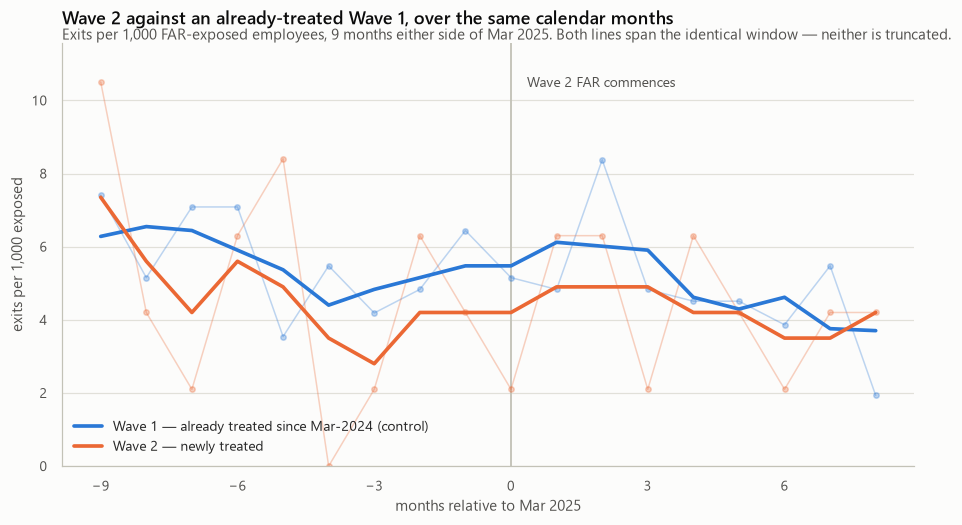

In [17]:
fig, ax = figure(
    "Wave 2 against an already-treated Wave 1, over the same calendar months",
    f"Exits per 1,000 FAR-exposed employees, {WINDOW} months either side of "
    f"{EVENT:%b %Y}. Both lines span the identical window — neither is truncated.",
    figsize=(10, 5.0),
)

# Wave 1 keeps slot 1 and Wave 2 slot 2, the same assignment as section 3, so
# a colour still means the same wave on every slide.
palette = {wave: SERIES[i] for i, wave in enumerate(sorted(cal_study["far_wave"].unique()))}
labels = {
    "Wave 1 (ADI, Mar-2024)": "Wave 1 — already treated since Mar-2024 (control)",
    "Wave 2 (Ins/Super, Mar-2025)": "Wave 2 — newly treated",
}

for wave, colour in palette.items():
    sub = cal_study[cal_study["far_wave"] == wave].sort_values("month_cal")
    smooth = sub["rate_per_1000"].rolling(3, center=True, min_periods=2).mean()
    ax.plot(sub["month_cal"], sub["rate_per_1000"], color=colour,
            lw=1, alpha=0.30, marker="o", markersize=3.5, zorder=2)
    ax.plot(sub["month_cal"], smooth, color=colour, lw=2.4,
            label=labels.get(wave, wave), zorder=3)

ax.axvline(0, color=INK["axis"], lw=1.2, zorder=1)

top = ax.get_ylim()[1]
ax.annotate("Wave 2 FAR commences", xy=(0.35, top * 0.94), fontsize=9,
            color=INK["secondary"])

ax.set(xlabel=f"months relative to {EVENT:%b %Y}",
       ylabel="exits per 1,000 exposed", ylim=(0, top * 1.05))
ax.set_xticks(range(-WINDOW, WINDOW, 3))
ax.legend(loc="lower left")
save_fig(fig, "a2_already_treated")
plt.show()

In [18]:
rows = []
for wave, sub in cal_study.groupby("far_wave", observed=True):
    pre = int(sub.loc[sub["month_cal"].between(-WINDOW, -1), "exits"].sum())
    post = int(sub.loc[sub["month_cal"].between(0, WINDOW - 1), "exits"].sum())
    n = int(denominator[wave])
    rows.append({
        "far_wave": wave,
        "at_event": "already treated" if wave.startswith("Wave 1") else "newly treated",
        "exposed": n,
        "exits_pre": pre,
        "exits_post": post,
        "pre_per_1000": round(1000 * pre / n, 1),
        "post_per_1000": round(1000 * post / n, 1),
        # Poisson standard error on the change, so the estimate carries its
        # own noise rather than being quoted as if it were precise.
        "se_change": round(1000 * np.sqrt(pre + post) / n, 1),
    })

staggered = pd.DataFrame(rows)
staggered["change"] = (staggered["post_per_1000"] - staggered["pre_per_1000"]).round(1)
staggered

,far_wave,at_event,exposed,exits_pre,exits_post,pre_per_1000,post_per_1000,se_change,change
0,"Wave 1 (ADI, Mar-2024)",already treated,3104,159,135,51.20,43.50,5.50,-7.70
1,"Wave 2 (Ins/Super, Mar-2025)",newly treated,476,21,18,44.10,37.80,13.10,-6.30


In [19]:
treated = staggered[staggered["at_event"] == "newly treated"].iloc[0]
control = staggered[staggered["at_event"] == "already treated"].iloc[0]

did_cal = treated["change"] - control["change"]
se_cal = np.sqrt(treated["se_change"] ** 2 + control["se_change"] ** 2)

# The within-wave estimate from section 4, recomputed rather than quoted.
_w2 = did[did["far_wave"].str.startswith("Wave 2")]
within = (_w2.loc[_w2["group"] == "FAR-exposed roles", "change"].iloc[0]
          - _w2.loc[_w2["group"] == "All other roles", "change"].iloc[0])

print(f"  Wave 2, newly treated      : {treated['change']:+.1f} per 1,000  "
      f"(+/- {treated['se_change']:.1f}, from {treated['exits_pre']} pre and "
      f"{treated['exits_post']} post exits)")
print(f"  Wave 1, already treated    : {control['change']:+.1f} per 1,000  "
      f"(+/- {control['se_change']:.1f})")
print(f"  difference-in-differences  : {did_cal:+.1f} per 1,000  (+/- {se_cal:.1f})")
print(f"  95% interval               : {did_cal - 1.96 * se_cal:+.1f} to "
      f"{did_cal + 1.96 * se_cal:+.1f} per 1,000")
print(f"\n  within-wave DiD (section 4): {within:+.1f} per 1,000")
print(f"  both estimates sit inside the other's interval — neither is "
      f"distinguishable from zero.")

  Wave 2, newly treated      : -6.3 per 1,000  (+/- 13.1, from 21 pre and 18 post exits)
  Wave 1, already treated    : -7.7 per 1,000  (+/- 5.5)
  difference-in-differences  : +1.4 per 1,000  (+/- 14.2)
  95% interval               : -26.4 to +29.2 per 1,000

  within-wave DiD (section 4): -3.5 per 1,000
  both estimates sit inside the other's interval — neither is distinguishable from zero.


### What the identified design says

| | exits pre | exits post | change per 1,000 |
|---|---|---|---|
| Wave 2 — newly treated Mar-2025 | 21 | 18 | -6.3 |
| Wave 1 — already treated since Mar-2024 | 159 | 135 | -7.7 |

Difference-in-differences: **+1.4 per 1,000**, against a standard error of
**14.2**. The 95% interval runs from -26.4 to +29.2 per 1,000.

Three things follow, and the third is the one to say out loud:

- **The truncation problem is gone.** Both arms are observed across the
  identical nine calendar months either side of March 2025. Neither can be
  flattered by a longer window — the defect that made every Wave 1 number in
  section 3 unusable.
- **The sign flips against section 4** — +1.4 here against -3.5 within-wave.
  Neither is distinguishable from zero, so this is not a contradiction; it is
  two noisy estimates of the same nothing.
- **This design cannot detect a FAR effect at any plausible size.** The entire
  Wave 2 exposed population is 476 people producing 39 exits across 18 months.
  The interval is wide enough to hold a large exodus and a large retention
  effect at once. The finding is *not identified* — which is not the same
  claim as *no effect*, and the difference matters if anyone asks.

Two assumptions this design buys, worth naming before a judge does. Using
Wave 1 as a control requires its own FAR response to have settled by mid-2024;
if banking staff were still reacting through 2025, the control is contaminated
and the comparison understates Wave 2. And the two arms are different
businesses — banking, technology and operations against insurance and wealth —
so parallel trends is an assumption *across sectors*, not within one.

## The Angle 2 story

1. **The naive answer is wrong, and it is the one everyone will produce.**
   A pre/post comparison on Wave 1 shows a 9x jump in exits among regulated
   staff. It is an artefact: the dataset starts six weeks before FAR
   commenced, so "before" is 1.4 months and "after" is nine. Leading with
   this — and then dismantling it — is a stronger opening than any finding.
2. **Only Wave 2 is identified**, and it does not support the FAR-exodus
   story. Regulated staff in insurance and superannuation left slightly
   *less* after commencement than their unregulated colleagues:
   a difference-in-differences of -3.5 per 1,000.
3. **`Executive Leadership` is unmapped** in `etl.FAR_WAVE_MAP` — 230 of the
   most FAR-exposed people in the company. Report them separately rather
   than letting them vanish into an `Unmapped` bucket.
4. **The seniority cut, where the effect should be strongest, is too small
   to test** — 22 and 6 employees. State the limitation; do not quote a rate.
5. **Name the confound before a judge does.** The Entity_B and Entity_C
   integrations run through the same window, and Entity_B's FAR-exposed staff
   leave at 17.1% against 8.0% for Entity_A. Acquisition integration is at
   least as plausible an explanation as the regulation.
6. **Section 7 runs the design the stagger was actually for, and it agrees.**
   Aligning on Wave 2's commencement sets Wave 2 (newly treated) against
   Wave 1 (already treated a year earlier) over the same calendar months, so
   neither arm is truncated — the defect that makes every Wave 1 number in
   section 3 unusable. The answer is +1.4 per 1,000, standard error 14.2.
   Quote the interval rather than the point: this dataset cannot detect a FAR
   effect of any plausible size, and *not identified* is a different claim
   from *no effect*.